In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1 โหลดข้อมูลทอง (จากไฟล์ CSV ที่เตรียมมา)
# ==============================

file_path = "2026.3.29XAUUSD_M1_UTCPlus07-M1-No Session.csv"

# อ่านไฟล์ CSV
data = pd.read_csv(file_path)

# รวม Date กับ Time เป็น Datetime และนำไปทำเป็น Index
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])
data.set_index('Datetime', inplace=True)
data.drop(columns=['Date', 'Time'], inplace=True)

# เนื่องจากข้อมูลที่คุณเตรียมมาเป็นความละเอียดราย 1 นาที (M1) 
# แต่กลยุทธ์เดิมออกแบบมาบนกราฟ 5 นาที (M5)
# เราจะทำการบีบอัด (Resample) จากแท่งเทียน M1 ให้กลายเป็น M5 (เพื่อให้ตรรกะเดิมยังทำงานได้ดี)
data = data.resample('5min').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

print("โหลดข้อมูลและแปลงเป็น M5 สำเร็จแล้ว!")
display(data.head())
print(f"จำนวนข้อมูลทั้งหมด: {len(data)} แท่ง")


โหลดข้อมูลและแปลงเป็น M5 สำเร็จแล้ว!


,Open,High,Low,Close,Volume
Datetime,,,,,
2025-01-02 06:00:00,2625.10,2626.01,2623.70,2624.90,104280
2025-01-02 06:05:00,2624.91,2625.45,2624.41,2625.13,81510
2025-01-02 06:10:00,2625.16,2625.30,2624.30,2624.59,70920
2025-01-02 06:15:00,2624.59,2624.89,2624.11,2624.22,52860
2025-01-02 06:20:00,2624.10,2624.13,2623.25,2623.49,65370


จำนวนข้อมูลทั้งหมด: 87681 แท่ง


# ATR

In [2]:
# ==============================
# 3 คำนวณ ATR
# ==============================

data["H-L"] = data["High"] - data["Low"]
data["H-C"] = abs(data["High"] - data["Close"].shift())
data["L-C"] = abs(data["Low"] - data["Close"].shift())

data["TR"] = data[["H-L","H-C","L-C"]].max(axis=1)

data["ATR"] = data["TR"].rolling(14).mean()

# Breakout Levels

In [3]:
# ==============================
# Breakout Levels
# ==============================

lookback = 50

data["HH"] = data["High"].rolling(lookback).max()
data["LL"] = data["Low"].rolling(lookback).min()

# Signal

In [14]:
# ==============================
# Signals
# ==============================

data["signal"] = 0

for i in range(lookback, len(data)):

    close = data["Close"].iloc[i]
    atr = data["ATR"].iloc[i]

    upper = data["HH"].iloc[i-1] + atr * 2
    lower = data["LL"].iloc[i-1] - atr * 2

    if close > upper:
        data.iloc[i, data.columns.get_loc("signal")] = 1

    elif close < lower:
        data.iloc[i, data.columns.get_loc("signal")] = -1

In [5]:
lookbacks = [10,20,30,40,50]
atr_multipliers = [0.5,1,1.5,2,3]
rr_values = [1.5,2,3]

results = []

for lookback in lookbacks:

    data["HH"] = data["High"].rolling(lookback).max()
    data["LL"] = data["Low"].rolling(lookback).min()

    for atr_mult in atr_multipliers:

        for rr in rr_values:

            balance = 200
            trades = []

            for i in range(lookback, len(data)):

                close = data["Close"].iloc[i]
                atr = data["ATR"].iloc[i]

                upper = data["HH"].iloc[i-1] + atr * atr_mult
                lower = data["LL"].iloc[i-1] - atr * atr_mult

                # BUY
                if close > upper:

                    entry = close
                    sl = entry - atr
                    tp = entry + atr * rr

                    for j in range(i+1, min(i+30,len(data))):

                        if data["Low"].iloc[j] <= sl:
                            trades.append(-1)
                            balance *= 0.99
                            break

                        if data["High"].iloc[j] >= tp:
                            trades.append(1)
                            balance *= 1.01
                            break

                # SELL
                elif close < lower:

                    entry = close
                    sl = entry + atr
                    tp = entry - atr * rr

                    for j in range(i+1, min(i+30,len(data))):

                        if data["High"].iloc[j] >= sl:
                            trades.append(-1)
                            balance *= 0.99
                            break

                        if data["Low"].iloc[j] <= tp:
                            trades.append(1)
                            balance *= 1.01
                            break

            if len(trades) > 0:

                trades = np.array(trades)

                winrate = np.sum(trades==1) / len(trades)

                results.append({
                    "lookback":lookback,
                    "ATR_mult":atr_mult,
                    "RR":rr,
                    "trades":len(trades),
                    "winrate":winrate,
                    "balance":balance
                })

results_df = pd.DataFrame(results)

results_df.sort_values("balance",ascending=False).head(10)

,lookback,ATR_mult,RR,trades,winrate,balance
72,50,3.0,1.5,30,0.433333,191.869597
73,50,3.0,2.0,30,0.433333,191.869597
57,40,3.0,1.5,34,0.441176,191.831225
58,40,3.0,2.0,34,0.441176,191.831225
42,30,3.0,1.5,38,0.394737,184.272309
43,30,3.0,2.0,38,0.394737,184.272309
74,50,3.0,3.0,30,0.333333,180.695620
59,40,3.0,3.0,34,0.352941,180.659483
44,30,3.0,3.0,38,0.315789,173.540778
27,20,3.0,1.5,46,0.347826,173.471372


In [15]:
# ==============================
# Backtest
# ==============================

balance = 50
initial_balance = balance
risk_per_trade = 0.1

equity = []
trades = []

for i in range(len(data)):

    if data["signal"].iloc[i] == 1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry - atr * 1
        tp = entry + atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):

            if data["Low"].iloc[j] <= sl:
                result = -1
                break

            if data["High"].iloc[j] >= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)

    elif data["signal"].iloc[i] == -1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry + atr * 1
        tp = entry - atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):

            if data["High"].iloc[j] >= sl:
                result = -1
                break

            if data["Low"].iloc[j] <= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)

    equity.append(balance)


📊 BACKTEST RESULTS 📊
จำนวนการเทรดทั้งหมด (Trades): 142
ฝั่งชนะ (Wins)             : 57
ฝั่งแพ้ (Losses)           : 85
อัตราการชนะ (Winrate)      : 40.14%
เงินทุนเริ่มต้น (Initial)    : 50.00
เงินทุนคงเหลือ (Final)       : 1.48


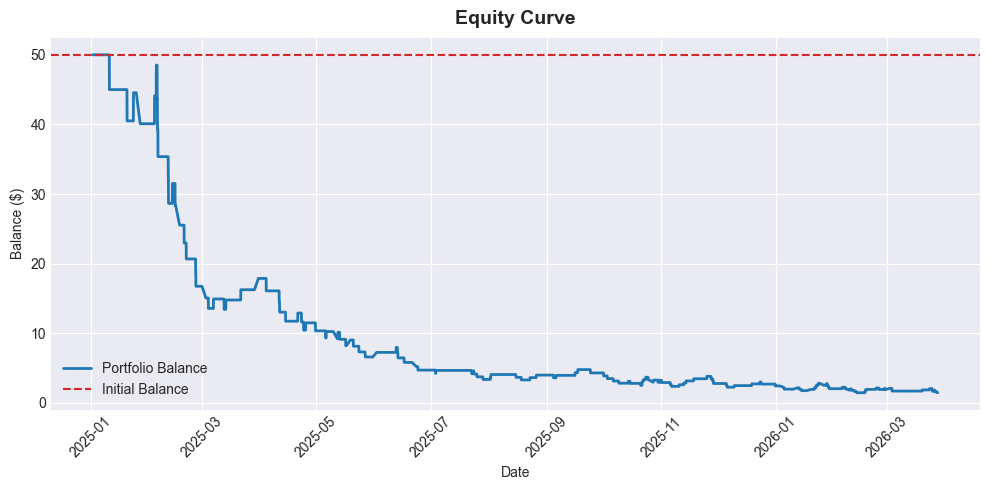

In [16]:
# -----------------------------------------------------------------
# --- สรุปผล Backtest ---
# -----------------------------------------------------------------
total_trades = len(trades)
wins = trades.count(1)
losses = trades.count(-1)
win_rate = (wins / total_trades * 100) if total_trades > 0 else 0

print("\n📊 BACKTEST RESULTS 📊")
print("="*30)
print(f"จำนวนการเทรดทั้งหมด (Trades): {total_trades}")
print(f"ฝั่งชนะ (Wins)             : {wins}")
print(f"ฝั่งแพ้ (Losses)           : {losses}")
print(f"อัตราการชนะ (Winrate)      : {win_rate:.2f}%")
print(f"เงินทุนเริ่มต้น (Initial)    : {initial_balance:.2f}")
print(f"เงินทุนคงเหลือ (Final)       : {balance:.2f}")
print("="*30)

# ==============================
# Equity Curve
# ==============================
import matplotlib.pyplot as plt

# ใช้สไตล์สำเร็จรูป ทำให้กราฟพล็อตออกมาสวยดูดีทันที
plt.style.use('seaborn-v0_8-darkgrid') 

plt.figure(figsize=(10, 5))

# สังเกตตรงนี้: เพิ่ม data.index เข้าไปเป็นแกน X
plt.plot(data.index, equity, color='#1f77b4', linewidth=2, label='Portfolio Balance')

# ขีดเส้นประสีแดง แนวนอน
plt.axhline(initial_balance, color='#d62728', linestyle='--', linewidth=1.5, label='Initial Balance')

plt.title("Equity Curve", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Date")           # เปลี่ยนชื่อแกน X เป็น Date
plt.ylabel("Balance ($)")    # แกน Y = ยอดเงินรวม
plt.legend()                 # ป้ายบอกกำกับเส้น

# หมุนตัวหนังสือแกน X นิดนึงให้ไม่ซ้อนทับกัน
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [17]:
# ==============================
# Backtest 
# ==============================

balance = 50
initial_balance = balance
risk_per_trade = 0.2

equity = []
trades = []

# เพิ่ม List สำหรับเก็บข้อมูลไปทำ ML
trade_records = [] 

for i in range(len(data)):

    if data["signal"].iloc[i] == 1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry - atr * 1
        tp = entry + atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):
            if data["Low"].iloc[j] <= sl:
                result = -1
                break
            if data["High"].iloc[j] >= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)
            
            # --------- ส่วนที่จัดเตรียมข้อมูลให้เพื่อนทำ ML ---------
            entry_time = data.index[i]
            hour = entry_time.hour
            
            # จัดกลุ่ม Session โดยอิงตามเวลาไทย (UTC+7)
            if 14 <= hour < 20:            # บ่าย 2 ถึงเกือบๆ 2 ทุ่ม
                session = 'London'
            elif hour >= 20 or hour < 4:   # 2 ทุ่ม ยาวไปถึงก่อนตี 4
                session = 'NY'
            else:                          # ตี 4 ถึงก่อนบ่าย 2
                session = 'Asia'

            # บันทึกเฉพาะสิ่งที่สำคัญจริงๆ
            ml_data = {
                'Entry_Time': entry_time,
                'Hour_of_Day': hour,
                'Day_of_Week': entry_time.dayofweek, # วันจันทร์=0, อาทิตย์=6
                'Session': session,
                'ATR': atr,
                'signal': 1,              # ซื้อ (Buy)
                'Trade_Type': 'Buy',
                'Label': 'TP' if result == 1 else 'SL'
            }
            trade_records.append(ml_data)

    elif data["signal"].iloc[i] == -1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry + atr * 1
        tp = entry - atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):
            if data["High"].iloc[j] >= sl:
                result = -1
                break
            if data["Low"].iloc[j] <= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)
            
            # --------- ส่วนที่จัดเตรียมข้อมูลให้เพื่อนทำ ML ---------
            entry_time = data.index[i]
            hour = entry_time.hour
            
            # จัดกลุ่ม Session โดยอิงตามเวลาไทย (UTC+7)
            if 14 <= hour < 20:
                session = 'London'
            elif hour >= 20 or hour < 4:
                session = 'NY'
            else:
                session = 'Asia'

            ml_data = {
                'Entry_Time': entry_time,
                'Hour_of_Day': hour,
                'Day_of_Week': entry_time.dayofweek,
                'Session': session,
                'ATR': atr,
                'signal': -1,             # ขาย (Sell)
                'Trade_Type': 'Sell',
                'Label': 'TP' if result == 1 else 'SL'
            }
            trade_records.append(ml_data)

    equity.append(balance)


# ==============================
# สร้าง DataFrame พิเศษสำหรับส่งให้เพื่อนทำ ML
# ==============================
df_ml = pd.DataFrame(trade_records)

print("ข้อมูล ML แบบ Clean แล้วพร้อมส่งให้เพื่อน, จำนวน Trade:", df_ml.shape[0])
display(df_ml.head(10))

# บันทึกเป็นไฟล์ CSV
df_ml.to_csv("clean_backtest_data_for_ml.csv", index=False)
print("👉 บันทึกไฟล์ 'clean_backtest_data_for_ml.csv' เรียบร้อยแล้ว เอาไปใช้ได้เลย!")


ข้อมูล ML แบบ Clean แล้วพร้อมส่งให้เพื่อน, จำนวน Trade: 142


,Entry_Time,Hour_of_Day,Day_of_Week,Session,ATR,signal,Trade_Type,Label
0,2025-01-10 20:30:00,20,4,NY,3.227143,-1,Sell,SL
1,2025-01-20 06:20:00,6,0,Asia,1.764286,-1,Sell,SL
2,2025-01-23 16:20:00,16,3,London,1.531429,-1,Sell,TP
3,2025-01-27 06:00:00,6,0,Asia,1.305000,-1,Sell,SL
4,2025-02-03 21:45:00,21,0,NY,2.547143,1,Buy,TP
5,2025-02-04 20:20:00,20,1,NY,2.356429,1,Buy,TP
6,2025-02-05 07:30:00,7,2,Asia,1.319286,1,Buy,SL
7,2025-02-05 11:10:00,11,2,Asia,1.567857,1,Buy,SL
8,2025-02-05 17:30:00,17,2,London,1.881429,1,Buy,SL
9,2025-02-11 06:00:00,6,1,Asia,1.408571,1,Buy,SL


👉 บันทึกไฟล์ 'clean_backtest_data_for_ml.csv' เรียบร้อยแล้ว เอาไปใช้ได้เลย!


จำนวนข้อมูลนำมา Train Model:  113
ความแม่นยำในการทำนาย (Accuracy): 41.38 %

--- ผลสรุปการทำนายบนชุด Test (ข้อสอบย่อย) ---
              precision    recall  f1-score   support

      SL (0)       0.50      0.65      0.56        17
      TP (1)       0.14      0.08      0.11        12

    accuracy                           0.41        29
   macro avg       0.32      0.37      0.33        29
weighted avg       0.35      0.41      0.37        29



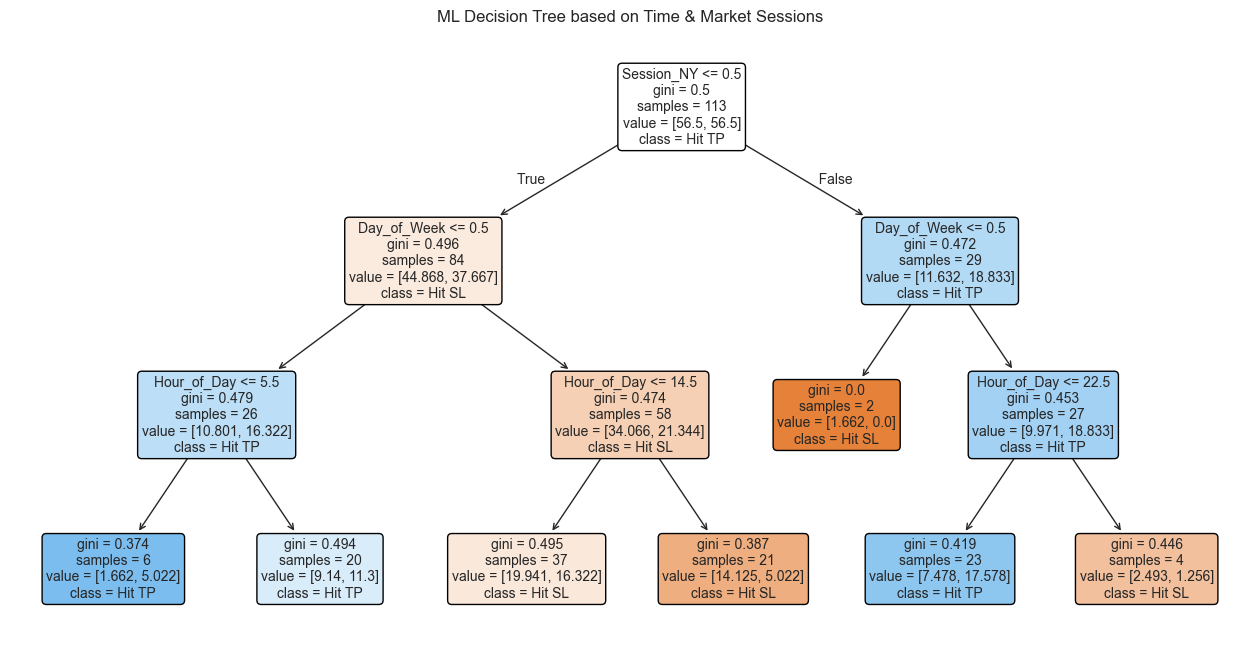


--- สัดส่วนความสำคัญของแต่ละตัวแปร (Feature Importances) ---


,Feature,Importance
1,Day_of_Week,0.478743
0,Hour_of_Day,0.338455
4,Session_NY,0.182802
2,Session_Asia,0.000000
3,Session_London,0.000000


In [18]:
# ==============================
# สร้าง ML: Decision Tree เพื่อคัดกรองไม้เข้า
# ==============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

# 1. เตรียมข้อมูลจากตาราง 
# (เพื่อนสามารถเปลี่ยนคำสั่งนี้เป็น pd.read_csv("clean_backtest_data_for_ml.csv") ตอนโยนไฟล์ไปได้เลย)
df_clean = df_ml.copy()

# แปลงเป้าหมาย (Label) : รอด (TP) จะเท่ากับ 1 หรือ เจ๊ง (SL) จะเท่ากับ 0 
df_clean['Target'] = df_clean['Label'].apply(lambda x: 1 if x == 'TP' else 0)

# ทำ One-Hot Encoding ให้กับตัวหนังสือ (Session และ Trade_Type) ให้กลายเป็น 1 กับ 0 
# เช่น มีคอลัมน์ชื่อ Session_NY ถ้าใช่มันจะเป็น 1 ไม่ใช่จะเป็น 0
df_clean = pd.get_dummies(df_clean, columns=['Session', 'Trade_Type'])

# ลิสต์รายชื่อคอลัมน์ที่โมเดลจะใช้เป็น X (Features) แบบเน้นๆ (เหลือแต่เวลา ความผันผวน และช่วงตลาด)
features = [
    'Hour_of_Day', 
    'Day_of_Week'
] 
# สมทบคอลัมน์ One-Hot ที่สร้างใหม่ทั้งหมดเข้าไป (Session กับ Trade Type)
features += [col for col in df_clean.columns if col.startswith('Session_')]
# features += [col for col in df_clean.columns if col.startswith('Trade_Type_')]

# แยกตัวหนังสือเป็น X (เกณฑ์ตัดสิน) ยละ y (เฉลยที่ AI ต้องเรียน)
X = df_clean[features]
y = df_clean['Target']

# 2. แบ่งข้อมูลเอาไว้สำหรับ สอน (Train) 80% และ ทดสอบความแม่น (Test) 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. สร้างแผนผังและสอนให้ Decision Tree เรียนจากข้อมูล
# max_depth=3 คือไม่ให้ AI ไปจำซับซ้อนเกินไป (กันจำข้อสอบ)
model = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. ทดสอบโมเดลโดยลองเดาบนชุด Test 
y_pred = model.predict(X_test)

print("จำนวนข้อมูลนำมา Train Model: ", X_train.shape[0])
print("ความแม่นยำในการทำนาย (Accuracy):", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\n--- ผลสรุปการทำนายบนชุด Test (ข้อสอบย่อย) ---")
print(classification_report(y_test, y_pred, target_names=['SL (0)', 'TP (1)']))

# 5. วาดแผนผังกระบวนการคิดของ AI 
plt.figure(figsize=(16, 8))
tree.plot_tree(
    model, 
    feature_names=features, 
    class_names=['Hit SL', 'Hit TP'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("ML Decision Tree based on Time & Market Sessions")
plt.show()

# 6. (Bonus) เรียงลำดับโชว์ว่า AI บอกว่าฟีเจอร์ไหนสำคัญสุดเวลาเทรด
importance_df = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
print("\n--- สัดส่วนความสำคัญของแต่ละตัวแปร (Feature Importances) ---")
display(importance_df.sort_values(by='Importance', ascending=False))
